In [ ]:
"""
Modified Dedalus script solving the 2D Poisson equation with mixed boundary conditions.
This script demonstrates solving a 2D Cartesian linear boundary value problem
and produces a plot of the solution. It should take just a few seconds to run.

We use a Fourier(x) * Chebyshev(y) discretization to solve the LBVP:
    dx(dx(u)) + dy(dy(u)) = f
    u(y=+-L/2) = 0
    u(x=+-L/2) = 0

For a scalar Laplacian on a finite interval, we need two tau terms. Here we
choose to lift them to the natural output (second derivative) basis.

To run and plot:
    $ python3 poisson.py
"""

import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3
import logging
logger = logging.getLogger(__name__)
from pysr import PySRRegressor

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


2026-05-11 10:36:55,251 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 3s, Remaining: 0s, Rate: 3.3e-01/s


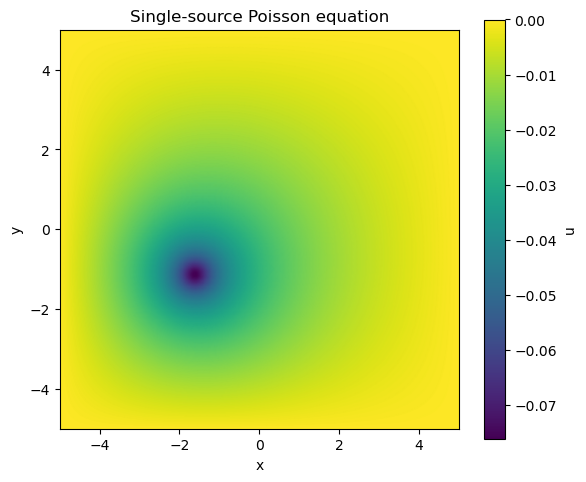

In [2]:



# Parameters
Lx, Ly = 10, 10
Nx, Ny = 512, 512
x_left, x_right = -Lx/2, Lx/2
y_bottom, y_top  = -Ly/2, Ly/2
dtype = np.float64

# Bases
coords = d3.CartesianCoordinates('x', 'y')
dist = d3.Distributor(coords, dtype=dtype)
xbasis = d3.Chebyshev(coords['x'], size=Nx, bounds=(x_left, x_right))
ybasis = d3.Chebyshev(coords['y'], size=Ny, bounds=(y_bottom, y_top))

# Fields
u = dist.Field(name='u', bases=(xbasis, ybasis))
tau_x1 = dist.Field(name='tau_x1', bases=ybasis)   # x left BC
tau_x2 = dist.Field(name='tau_x2', bases=ybasis)   # x right BC
tau_y1 = dist.Field(name='tau_y1', bases=xbasis)   # y bottom BC
tau_y2 = dist.Field(name='tau_y2', bases=xbasis)   # y top BC

# Forcing — single Gaussian source at a random location within a circle of radius 2
x, y = dist.local_grids(xbasis, ybasis)
f = dist.Field(bases=(xbasis, ybasis))
r_source = 0.15

rng = np.random.default_rng()
r = np.sqrt(rng.uniform(0, 2**2))
a = rng.uniform(0, 2*np.pi)
x0, y0 = r * np.cos(a), r * np.sin(a)

f['g'] = np.exp(-((x - x0)**2 + (y - y0)**2) / (2*r_source**2))

# Substitutions
lift_basis_x = xbasis.derivative_basis(2)
lift_basis_y = ybasis.derivative_basis(2)
lift_x = lambda A, n: d3.Lift(A, lift_basis_x, n)
lift_y = lambda A, n: d3.Lift(A, lift_basis_y, n)

# Problem
problem = d3.LBVP([u, tau_x1, tau_x2, tau_y1, tau_y2], namespace=locals())
problem.add_equation("lap(u) + lift_x(tau_x1,-1) + lift_x(tau_x2,-2) + lift_y(tau_y1,-1) + lift_y(tau_y2,-2) = f")
problem.add_equation("u(x=x_left) = 0")
problem.add_equation("u(x=x_right) = 0")
problem.add_equation("u(y=y_bottom) = 0")
problem.add_equation("u(y=y_top) = 0")

# Solver
solver = problem.build_solver()
solver.solve()

# Gather global data
x = xbasis.global_grid(dist, scale=1)
y = ybasis.global_grid(dist, scale=1)
ug = u.allgather_data('g')

# Plot
if dist.comm.rank == 0:
    fig, ax = plt.subplots(figsize=(6, 5))
    pcm = ax.pcolormesh(x.ravel(), y.ravel(), ug.T, cmap='viridis', shading='gouraud', rasterized=True)
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title("Single-source Poisson equation")
    plt.colorbar(pcm, ax=ax, label='u')
    plt.tight_layout()
    #plt.savefig('poisson.pdf')
    #plt.savefig('poisson.png', dpi=200)


In [3]:
# Dataset generation for symbolic regression of the Green's function
# Self-contained: builds its own solver independent of the visualization cell above.

import numpy as np
import dedalus.public as d3

# --- Domain ---
Lx, Ly = 10, 10
Nx, Ny = 512, 512
x_left, x_right = -Lx/2, Lx/2
y_bottom, y_top  = -Ly/2, Ly/2
dtype = np.float64

coords_ds = d3.CartesianCoordinates('x', 'y')
dist_ds   = d3.Distributor(coords_ds, dtype=dtype)
xbasis_ds = d3.Chebyshev(coords_ds['x'], size=Nx, bounds=(x_left,  x_right))
ybasis_ds = d3.Chebyshev(coords_ds['y'], size=Ny, bounds=(y_bottom, y_top))

# --- Fields ---
u_ds      = dist_ds.Field(name='u',      bases=(xbasis_ds, ybasis_ds))
tau_x1_ds = dist_ds.Field(name='tau_x1', bases=ybasis_ds)
tau_x2_ds = dist_ds.Field(name='tau_x2', bases=ybasis_ds)
tau_y1_ds = dist_ds.Field(name='tau_y1', bases=xbasis_ds)
tau_y2_ds = dist_ds.Field(name='tau_y2', bases=xbasis_ds)
f_ds      = dist_ds.Field(bases=(xbasis_ds, ybasis_ds))

lift_basis_x_ds = xbasis_ds.derivative_basis(2)
lift_basis_y_ds = ybasis_ds.derivative_basis(2)
lift_x_ds = lambda A, n: d3.Lift(A, lift_basis_x_ds, n)
lift_y_ds = lambda A, n: d3.Lift(A, lift_basis_y_ds, n)

problem_ds = d3.LBVP(
    [u_ds, tau_x1_ds, tau_x2_ds, tau_y1_ds, tau_y2_ds],
    namespace={
        'u': u_ds, 'tau_x1': tau_x1_ds, 'tau_x2': tau_x2_ds,
        'tau_y1': tau_y1_ds, 'tau_y2': tau_y2_ds,
        'f': f_ds, 'lift_x': lift_x_ds, 'lift_y': lift_y_ds,
        'lap': d3.lap,
        'x_left': x_left, 'x_right': x_right,
        'y_bottom': y_bottom, 'y_top': y_top,
    }
)
problem_ds.add_equation("lap(u) + lift_x(tau_x1,-1) + lift_x(tau_x2,-2) + lift_y(tau_y1,-1) + lift_y(tau_y2,-2) = f")
problem_ds.add_equation("u(x=x_left)   = 0")
problem_ds.add_equation("u(x=x_right)  = 0")
problem_ds.add_equation("u(y=y_bottom) = 0")
problem_ds.add_equation("u(y=y_top)    = 0")
solver_ds = problem_ds.build_solver()

x_grid_ds = xbasis_ds.global_grid(dist_ds, scale=1)
y_grid_ds = ybasis_ds.global_grid(dist_ds, scale=1)
x_local_ds, y_local_ds = dist_ds.local_grids(xbasis_ds, ybasis_ds)

# --- Sampling parameters ---
r_source_ds = 0.15
r_min = 3 * r_source_ds
r_max = 5.0
N_train = 50

def generate_dataset(n_samples, seed):
    rng = np.random.default_rng()
    X_list, y_list = [], []
    for _ in range(n_samples):
        r_pos = np.sqrt(rng.uniform(0, 1**2))
        a_pos = rng.uniform(0, 2 * np.pi)
        x0_i  = r_pos * np.cos(a_pos)
        y0_i  = r_pos * np.sin(a_pos)

        f_ds['g'] = np.exp(-((x_local_ds - x0_i)**2 + (y_local_ds - y0_i)**2) / (2 * r_source_ds**2))
        solver_ds.solve()

        ug_i    = u_ds.allgather_data('g')
        r_field = np.sqrt((x_grid_ds - x0_i)**2 + (y_grid_ds - y0_i)**2)

        r_flat = r_field.ravel()
        u_flat = ug_i.ravel()
        mask   = (r_flat > r_min) & (r_flat < r_max)
        X_list.append(r_flat[mask])
        y_list.append(u_flat[mask])

    return np.concatenate(X_list), np.concatenate(y_list)

X_train, y_train = generate_dataset(N_train, seed=0)


np.save('greens_function_train.npy', np.stack([X_train, y_train], axis=1))

print(f"Train: {len(X_train)} samples, r in [{X_train.min():.3f}, {X_train.max():.3f}]")

2026-05-11 10:37:52,902 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 3s, Remaining: 0s, Rate: 3.1e-01/s
Train: 6494044 samples, r in [0.450, 5.000]


In [ ]:
# Load training dataset
data_train = np.load('greens_function_train.npy')
X_sr = data_train[:, 0].reshape(-1, 1)
y_sr = data_train[:, 1]

# Subsample to keep runtime manageable
rng_sr = np.random.default_rng(seed=1)
idx = rng_sr.choice(len(X_sr), size=10000, replace=False)
X_sub, y_sub = X_sr[idx], y_sr[idx]

 niterations=30,
    binary_operators=["+", "*", "^"],
    unary_operators=["log", "cos", "sin", "exp", "inv"],
    delete_tempfiles=True,
    nested_constraints={
        "sin": {"sin": 0, "cos": 0},
        "cos": {"cos": 0, "sin": 0},
        "exp": {"exp": 0, "log": 0},
        "log": {"log": 0, "exp": 0},
        "inv": {"inv": 0},
    },
model.fit(X_sub, y_sub)


/opt/miniconda3/envs/dedalus3/lib/python3.14/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...


2026-05-11 10:38:56,960 pysr.sr 0/1 INFO :: Compiling Julia backend...


/opt/miniconda3/envs/dedalus3/lib/python3.14/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 6.880e+01
Progress: 1 / 930 total iterations (0.108%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           9.994e-05  0.000e+00  y = -0.0058735
15          7.300e-05  2.244e-02  y = sin(sin(sin(((0.057792 ^ sin(0.79384 ^ (x₀ ^ -0.52506)...
                                      )) ^ 2.1593) * -0.88471)))
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.710e+03
Progress: 29 / 930 total iterations (3.118%)
════════════════════════════════════════════════════════════════════════════════════════════════════
─────────────

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '*', ...]"
,unary_operators,"['log', 'cos', ...]"
,expression_spec,None
,niterations,30
,populations,31
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


  - outputs/20260511_103856_Zk9oDF/hall_of_fame.csv


In [5]:
print(model)

PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                       -0.009553819   
	1        0.785142                     (0.5376073 ^ x0) * -0.07286439   
	2  >>>>  0.382418                 log(x0 * 0.19096056) * 0.022646919   
	3        0.002166  ((0.7203296 ^ (1.5836596 ^ x0)) + (0.2719845 ^...   
	4        0.003428  ((0.28097078 ^ x0) + (0.74731606 ^ ((1.6081134...   
	5        0.001659  ((0.74696094 ^ ((1.1032813 ^ sin(1.6074045 ^ x...   
	6        0.000059  ((0.28125033 ^ x0) + (0.74696094 ^ ((1.1032813...   
	7        0.001557  ((0.28125033 ^ x0) + (0.74696094 ^ ((1.1032813...   
	8        0.000037  sin(((0.28125033 ^ x0) + (0.74696094 ^ ((1.103...   
	9        0.000061  -0.051345848 * ((0.28125033 ^ x0) + (0.7469609...   
	
	       loss  complexity  
	0  0.000086           1  
	1  0.000004           5  
	2  0.000003           6  
	3  0.000003          11  
	4  0.000003          13  
	5  

In [6]:
# Subsample to keep runtime manageable
rng_sr = np.random.default_rng(seed=1)
idx = rng_sr.choice(len(X_sr), size=10000, replace=False)
X_sub, y_sub = X_sr[idx], y_sr[idx]

model_no_powers = PySRRegressor(
    niterations=30,
    binary_operators=["+", "*"],
    unary_operators=["log", "cos", "sin", "exp"],
    delete_tempfiles=True,
)
model_no_powers.fit(X_sub, y_sub)

/opt/miniconda3/envs/dedalus3/lib/python3.14/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.570e+03
Progress: 23 / 930 total iterations (2.473%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.639e-05  0.000e+00  y = -0.0095538
5           6.141e-05  8.534e-02  y = exp(sin(x₀)) * -0.0052669
6           4.830e-05  2.401e-01  y = -0.050543 * sin(cos(log(x₀)))
7           1.908e-05  9.288e-01  y = exp(sin(x₀) + 0.70676) * -0.0053745
10          9.107e-06  2.465e-01  y = sin(((x₀ + 1.8013) * -0.10061) + 0.66886) * -0.078122
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 4.900e+03
Progress: 66 / 930 to

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '*']"
,unary_operators,"['log', 'cos', ...]"
,expression_spec,None
,niterations,30
,populations,31
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


  - outputs/20260511_104508_QKNScq/hall_of_fame.csv


In [7]:
print(model_no_powers)

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                       -0.009553822   
	1         0.584532                  (x0 * 0.008118734) + -0.039303645   
	2   >>>>  1.184858             (log(x0) * 0.022647839) + -0.037497327   
	3         0.000047          sin(log(x0) * 0.022653494) + -0.037500024   
	4         0.000043     sin(sin(log(x0) * 0.022665486)) + -0.037511762   
	5         0.000049  sin(sin(sin(log(x0) * 0.022664605))) + -0.0375...   
	6         0.001284  (log(x0) * ((x0 * -7.414586e-5) + 0.023042256)...   
	7         0.005364  (log(x0) * ((cos(x0) * -0.00020511629) + 0.022...   
	8         0.000053  (log(x0) * (sin(0.022652365) + (cos(x0) * -0.0...   
	9         0.010315  ((((x0 + sin(x0)) * -0.038912147) + -1.5110259...   
	10        0.000002  (((x0 + sin(x0)) * -0.038912147) + (-1.5110259...   
	11        0.000965  (log(x0 + ((sin(x0) + x0) * (x0 * -0.03632755)...   
	12      